# MIO-TCD Localization Dataset Exploration

This notebook explores the MIO-TCD-Localization dataset metadata to gain insights into the distribution of classes, object sizes, and image statistics.

## Dataset Overview
The dataset consists of images and a ground truth CSV file (`gt_train.csv`) with the following columns:
- `image_id`: Unique identifier for the image.
- `label`: Category of the object.
- `x1`, `y1`: Top-left corner of the bounding box.
- `x2`, `y2`: Bottom-right corner of the bounding box.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set paths
base_path = r"C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization"
gt_train_path = os.path.join(base_path, 'gt_train.csv')

# Load the data
cols = ['image_id', 'label', 'x1', 'y1', 'x2', 'y2']
df = pd.read_csv(gt_train_path, names=cols, header=None, dtype={'image_id': str})

print(f"Total annotations: {len(df)}")
print(f"Total unique images: {df['image_id'].nunique()}")
df.head()

Total annotations: 351549
Total unique images: 110000


,image_id,label,x1,y1,x2,y2
0,00000000,pickup_truck,213,34,255,50
1,00000000,car,194,78,273,122
2,00000000,car,155,27,183,35
3,00000000,articulated_truck,43,25,109,55
4,00000000,car,106,32,124,45


## 1. Class Distribution
Let's see how many objects belong to each class.

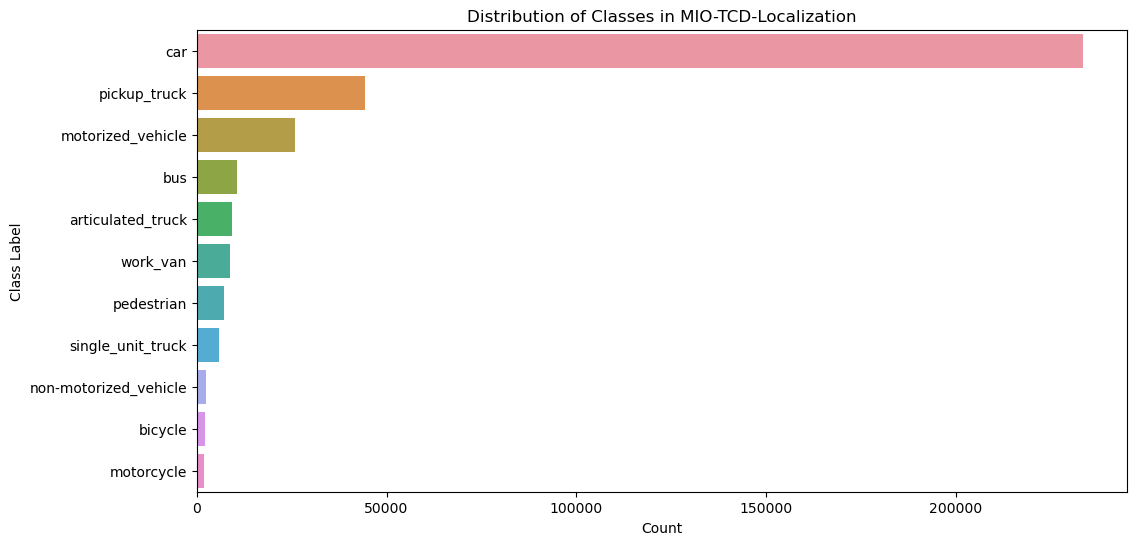

Class Counts:
label
car                      233497
pickup_truck              44283
motorized_vehicle         25845
bus                       10598
articulated_truck          9301
work_van                   8709
pedestrian                 7128
single_unit_truck          5741
non-motorized_vehicle      2350
bicycle                    2260
motorcycle                 1837
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='label', order=df['label'].value_counts().index)
plt.title('Distribution of Classes in MIO-TCD-Localization')
plt.xlabel('Count')
plt.ylabel('Class Label')
plt.show()

print("Class Counts:")
print(df['label'].value_counts())

## 2. Object Density (Objects per Image)
How many objects are typically found in a single image?

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


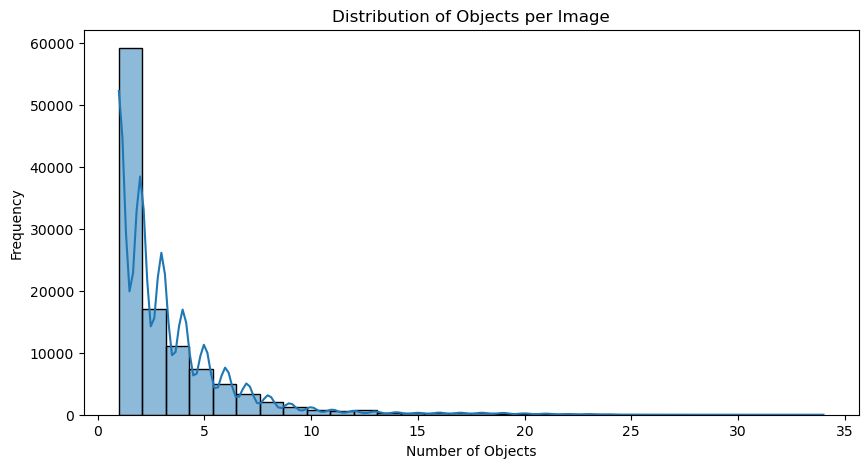

Average objects per image: 3.20
Max objects in an image: 34


In [4]:
objects_per_image = df.groupby('image_id').size()

plt.figure(figsize=(10, 5))
sns.histplot(objects_per_image, bins=30, kde=True)
plt.title('Distribution of Objects per Image')
plt.xlabel('Number of Objects')
plt.ylabel('Frequency')
plt.show()

print(f"Average objects per image: {objects_per_image.mean():.2f}")
print(f"Max objects in an image: {objects_per_image.max()}")

## Most object count image visualized

Image with highest object count: 00022157
Number of objects: 34
Loading image from:
C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization\train\00022157.jpg


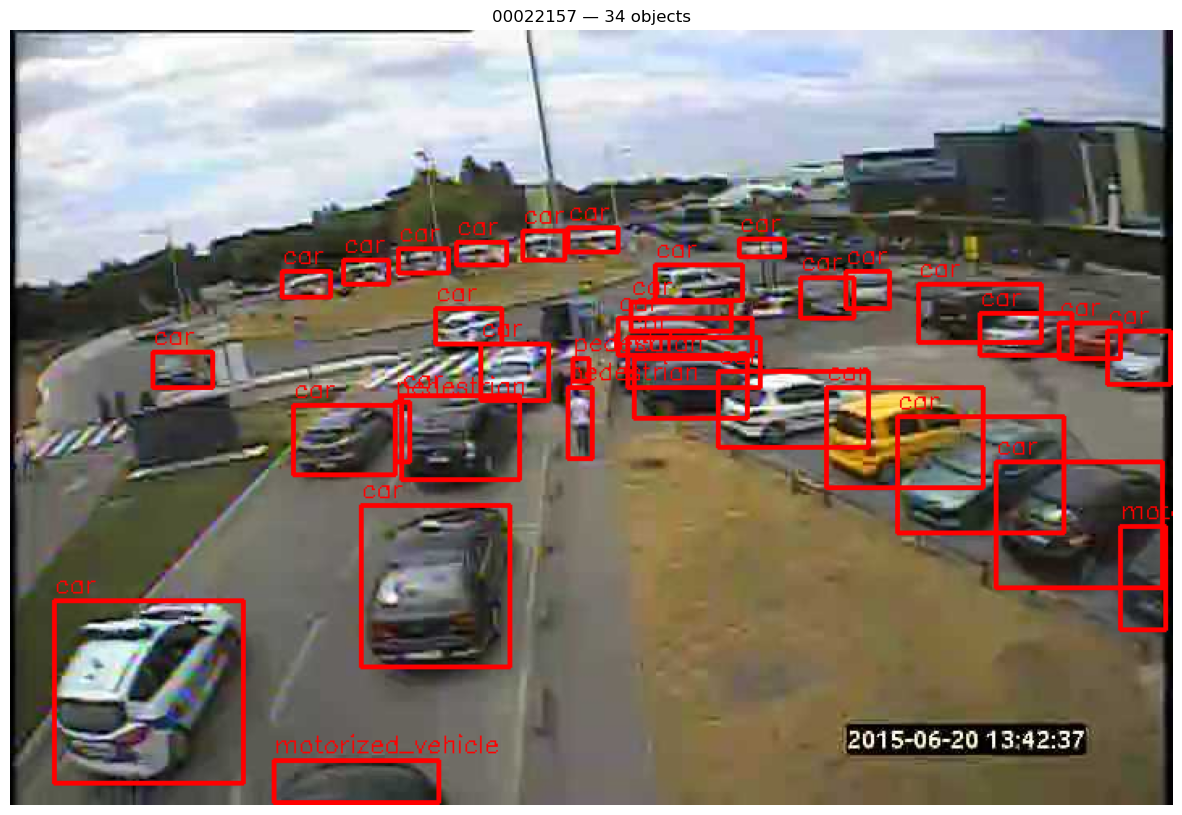

In [5]:
import cv2
import matplotlib.pyplot as plt

# Find image with max objects
objects_per_image = df.groupby('image_id').size()

max_count = objects_per_image.max()
max_image_id = objects_per_image.idxmax()

print(f"Image with highest object count: {max_image_id}")
print(f"Number of objects: {max_count}")

# Images folder
images_path = os.path.join(base_path, 'train')

# Add image extension
img_filename = max_image_id + '.jpg'

# Full image path
img_path = os.path.join(images_path, img_filename)

print("Loading image from:")
print(img_path)

# Load image
img = cv2.imread(img_path)

# Check if image loaded correctly
if img is None:
    print("ERROR: Image not found.")
else:
    # Convert BGR -> RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get bounding boxes for this image
    img_boxes = df[df['image_id'] == max_image_id]

    # Draw boxes
    for _, row in img_boxes.iterrows():
        x1, y1, x2, y2 = map(int, [row['x1'], row['y1'], row['x2'], row['y2']])
        label = row['label']

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        cv2.putText(
            img,
            str(label),
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            1
        )

    # Display image
    plt.figure(figsize=(15, 15))
    plt.imshow(img)
    plt.title(f"{max_image_id} — {max_count} objects")
    plt.axis('off')
    plt.show()

## 3. Bounding Box Dimensions
Analyzing the width, height, and area of the bounding boxes.

C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Dell\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


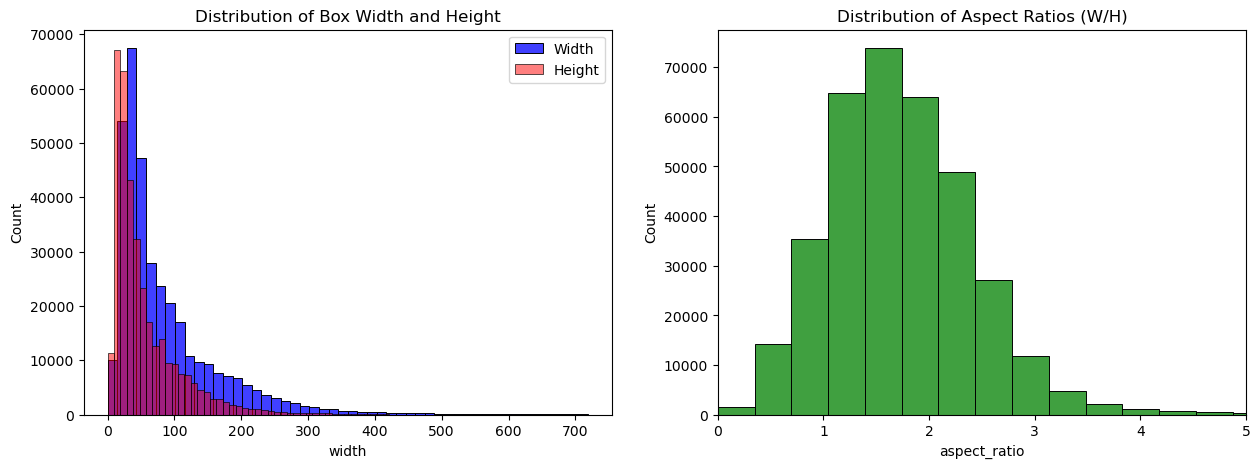

Box Statistics:
               width         height           area  aspect_ratio
count  351549.000000  351549.000000  351549.000000  3.515490e+05
mean       87.301853      55.209294    8586.202930           inf
std        82.406655      52.336099   18555.580862           NaN
min         0.000000       0.000000       0.000000  0.000000e+00
25%        34.000000      21.000000     714.000000  1.258065e+00
50%        56.000000      36.000000    1947.000000  1.666667e+00
75%       111.000000      72.000000    7560.000000  2.150000e+00
max       719.000000     479.000000  335104.000000           inf


In [6]:
df['width'] = df['x2'] - df['x1']
df['height'] = df['y2'] - df['y1']
df['area'] = df['width'] * df['height']
df['aspect_ratio'] = df['width'] / df['height']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['width'], bins=50, ax=axes[0], color='blue', label='Width')
sns.histplot(df['height'], bins=50, ax=axes[0], color='red', label='Height', alpha=0.5)
axes[0].set_title('Distribution of Box Width and Height')
axes[0].legend()

sns.histplot(df['aspect_ratio'], bins=50, ax=axes[1], color='green')
axes[1].set_title('Distribution of Aspect Ratios (W/H)')
axes[1].set_xlim(0, 5) # Truncate for visibility
plt.show()

print("Box Statistics:")
print(df[['width', 'height', 'area', 'aspect_ratio']].describe())

## 4. Class-wise Box Sizes
Do some classes tend to be larger or smaller?

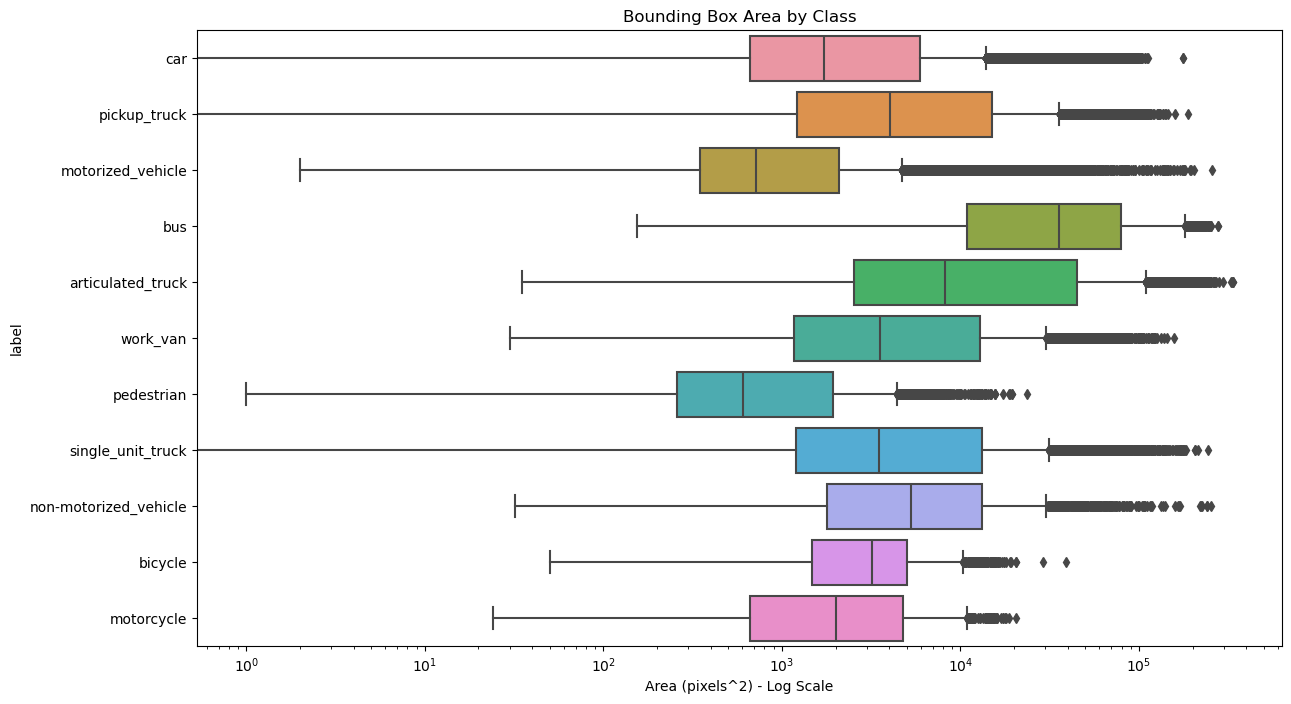

In [7]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='area', y='label', order=df['label'].value_counts().index)
plt.title('Bounding Box Area by Class')
plt.xscale('log') # Use log scale because area can vary significantly
plt.xlabel('Area (pixels^2) - Log Scale')
plt.show()

## 5. Visualizing the Most Congested Image
Let's find and display the image with the highest number of objects to visualize a 'High Congestion' scenario.

Image ID: 00022157 contains 34 objects.


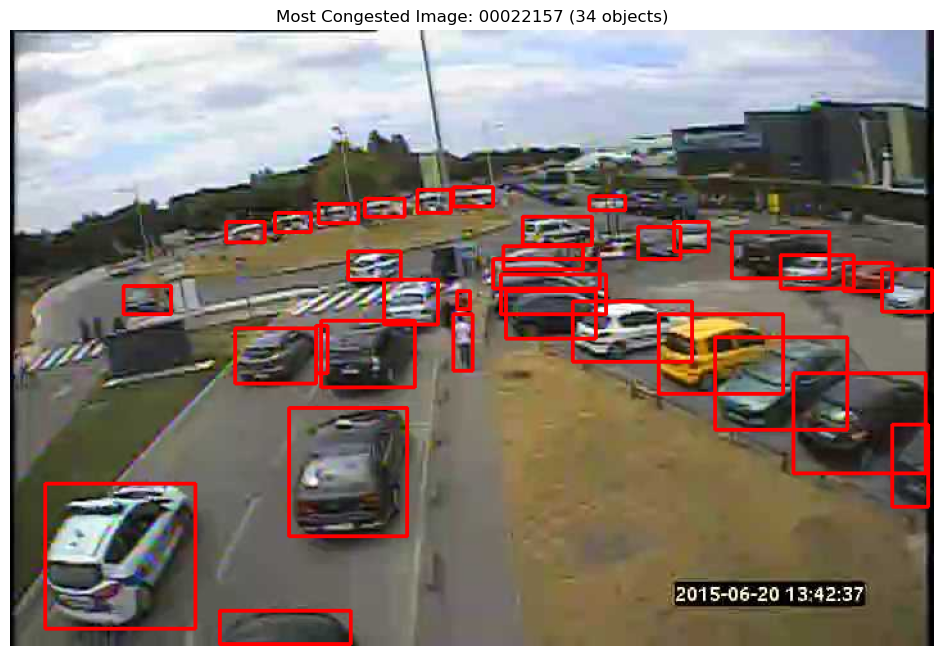

In [8]:
import cv2
import os

# Find the image ID with the maximum object count
max_img_id = df.groupby('image_id').size().idxmax()
max_count = df.groupby('image_id').size().max()

print(f"Image ID: {max_img_id} contains {max_count} objects.")

# Path to the image (assuming it's in the train folder)
img_path = os.path.join(base_path, 'train', f"{max_img_id}.jpg")

img = cv2.imread(img_path)
if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Draw bounding boxes
    for _, row in df[df['image_id'] == max_img_id].iterrows():
        cv2.rectangle(img_rgb, (int(row['x1']), int(row['y1'])), (int(row['x2']), int(row['y2'])), (255, 0, 0), 2)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.title(f"Most Congested Image: {max_img_id} ({max_count} objects)")
    plt.axis('off')
    plt.show()
else:
    print("Image not found. Please check the 'base_path' and 'train' directory.")

## 6. Filtering Out Pedestrians
Since our goal is to identify vehicles that create traffic congestion, we will exclude 'pedestrian' from the object count.
Since our object count became 32 for the max objects image we confirm that pedestrians are being excluded since the max image had 2 pedestrians

In [9]:
# Create a filtered dataframe excluding pedestrians
df_vehicles = df[df['label'] != 'pedestrian']

print(f"Original annotations: {len(df)}")
print(f"Annotations after excluding pedestrians: {len(df_vehicles)}")

# Recalculate max object count with only vehicles
vehicle_counts = df_vehicles.groupby('image_id').size()
new_max_id = vehicle_counts.idxmax()
new_max_val = vehicle_counts.max()

print(f"\nNew Most Congested Image (Vehicles only): {new_max_id}")
print(f"Vehicle Count: {new_max_val}")

Original annotations: 351549
Annotations after excluding pedestrians: 344421

New Most Congested Image (Vehicles only): 00039024
Vehicle Count: 32


## Summary of Insights
- **Class Balance:** Identify if there's significant class imbalance (e.g., more cars than buses).
- **Image Density:** Understand if images are crowded or sparse.
- **Object Scale:** Determine the range of object sizes, which is crucial for choosing an object detection model (e.g., YOLO vs. Faster R-CNN).
- **Aspect Ratios:** Useful for configuring anchor boxes in certain detection architectures.

In [ ]:
##FGSM Attacker 

In [11]:
import pandas as pd
import numpy as np

# Continuing from your notebook's df_vehicles
vehicle_counts = df_vehicles.groupby('image_id').size().reset_index(name='vehicle_count')

# Use tertiles so classes are balanced — adjust if your distribution is skewed
low_thresh, high_thresh = vehicle_counts['vehicle_count'].quantile([0.33, 0.66])
print(f"Low/Medium boundary: {low_thresh:.1f} vehicles")
print(f"Medium/High boundary: {high_thresh:.1f} vehicles")

def bin_congestion(count):
    if count <= low_thresh:
        return 0  # Low
    elif count <= high_thresh:
        return 1  # Medium
    else:
        return 2  # High

vehicle_counts['congestion_label'] = vehicle_counts['vehicle_count'].apply(bin_congestion)
print(vehicle_counts['congestion_label'].value_counts())

# This becomes your single source of truth — one row per image
vehicle_counts.to_csv('congestion_labels.csv', index=False)

Low/Medium boundary: 2.0 vehicles
Medium/High boundary: 3.0 vehicles
congestion_label
0    60133
2    33094
1    16761
Name: count, dtype: int64


In [16]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 3)  # Low, Medium, High
model = model.to(device)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(10):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    print(f"Epoch {epoch+1} | Val accuracy: {correct/total:.2%}")

torch.save(model, 'models/baseline_v1.pt')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Dell/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:17<00:00, 5.79MB/s]


NameError: name 'train_ds' is not defined

In [15]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split

# --- Paths ---
base_path = r"C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization"
labels_path = r"C:\Users\Dell\Downloads\MIO-TCD-Localization\MIO-TCD-Localization\congestion_labels.csv"
image_dir = os.path.join(base_path, "train")

# --- Load precomputed congestion labels ---
vehicle_counts = pd.read_csv(labels_path, dtype={'image_id': str})
print(vehicle_counts.head())
print(vehicle_counts['congestion_label'].value_counts())

# --- Dataset class ---
class MIOTCDCongestionDataset(Dataset):
    def __init__(self, labels_df, image_dir, transform=None):
        self.labels_df = labels_df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        img_path = os.path.join(self.image_dir, f"{row['image_id']}.jpg")
        image = Image.open(img_path).convert('RGB')
        label = int(row['congestion_label'])
        if self.transform:
            image = self.transform(image)
        return image, label

# --- Stratified subset + split ---
subset = vehicle_counts.groupby('congestion_label').sample(n=2000, random_state=42)

train_df, temp_df = train_test_split(
    subset, test_size=0.3, stratify=subset['congestion_label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['congestion_label'], random_state=42
)

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

train_ds = MIOTCDCongestionDataset(train_df, image_dir, transform)
val_ds   = MIOTCDCongestionDataset(val_df, image_dir, transform)
test_ds  = MIOTCDCongestionDataset(test_df, image_dir, transform)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# --- Model ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --- Training loop ---
for epoch in range(10):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    print(f"Epoch {epoch+1} | Val accuracy: {correct/total:.2%}")

os.makedirs('models', exist_ok=True)
torch.save(model, 'models/baseline_v1.pt')

   image_id  vehicle_count  congestion_label
0  00000000              5                 2
1  00000001              6                 2
2  00000002              1                 0
3  00000003              2                 0
4  00000004              1                 0
congestion_label
0    60133
2    33094
1    16761
Name: count, dtype: int64
Train: 4200 | Val: 900 | Test: 900
Epoch 1 | Val accuracy: 73.11%
Epoch 2 | Val accuracy: 75.56%


In [ ]:
import numpy as np
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod

model.eval()
classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 224, 224),
    nb_classes=3,
    clip_values=(0.0, 1.0),
    device_type='gpu' if torch.cuda.is_available() else 'cpu'
)

# Convert test set to numpy
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
x_test_list, y_test_list = [], []
for images, labels in test_loader:
    x_test_list.append(images.numpy())
    y_test_list.append(labels.numpy())
x_test = np.concatenate(x_test_list)
y_test = np.concatenate(y_test_list)

clean_preds = np.argmax(classifier.predict(x_test), axis=1)
clean_acc = np.mean(clean_preds == y_test)
print(f"Clean accuracy: {clean_acc:.2%}")

epsilons = [0.01, 0.05, 0.10, 0.20]
results = []
for eps in epsilons:
    attack = FastGradientMethod(estimator=classifier, eps=eps)
    x_adv = attack.generate(x=x_test)
    adv_preds = np.argmax(classifier.predict(x_adv), axis=1)
    acc = np.mean(adv_preds == y_test)
    asr = np.mean(adv_preds != clean_preds)
    results.append({'eps': eps, 'attacked_acc': acc, 'asr': asr})
    print(f"ε={eps} | Accuracy: {acc:.2%} | ASR: {asr:.2%}")

pd.DataFrame(results).to_csv('outputs/fgsm_results.csv', index=False)